In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--force-reinstall", "--no-cache-dir",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "torchaudio==2.7.1",
    "transformers==4.52.4",
    "accelerate==1.7.0",
    "datasets==3.6.0",
    "evaluate==0.4.3",
    "tokenizers==0.21.1"
])

0

In [1]:

import transformers
import accelerate
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers: 4.52.4
Accelerate: 1.7.0
Datasets: 3.6.0
Torch: 2.7.1+cu126
CUDA available: True


In [2]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report
from scipy.stats import pearsonr

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)



In [3]:
from google.colab import drive
drive.mount("/content/drive")

# =========================================================
# 2. BASIC SETUP
# =========================================================
SEED = 42
K = 5

MODEL_NAME = "roberta-base"

LOG_FILE = "/content/drive/MyDrive/RoBERTa_SingleStep_KFold_Clean_Log.csv"
PLOT_DIR = "/content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots"

os.makedirs("/content/drive/MyDrive", exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)



Mounted at /content/drive


In [4]:
# =========================================================
# 3. LOAD BRIGHTER DATASET
# =========================================================
print("\nLoading BRIGHTER dataset...")

train_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="train"
)

dev_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="dev"
)

test_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="test"
)

train_df = train_data.to_pandas()
dev_df = dev_data.to_pandas()
test_df = test_data.to_pandas()

print("\nOriginal split sizes:")
print("Train:", len(train_df))
print("Dev  :", len(dev_df))
print("Test :", len(test_df))

print("\nSample data:")
print(train_df.head())

# =========================================================
# 4. LABEL CONFIGURATION
# =========================================================
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
LEVELS = [1, 2, 3]

LABELS = [f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
NUM_LABELS = len(LABELS)

print("\nLabels:")
print(LABELS)
print("Number of labels:", NUM_LABELS)

# =========================================================
# 5. SINGLE-STEP LABEL CONVERSION
# =========================================================
def convert_single_step_labels(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    for emotion in EMOTIONS:
        df[f"{emotion}_1"] = (df[emotion] == 1).astype(int)
        df[f"{emotion}_2"] = (df[emotion] == 2).astype(int)
        df[f"{emotion}_3"] = (df[emotion] == 3).astype(int)

    return df[["text"] + LABELS]

train_single = convert_single_step_labels(train_df)
dev_single = convert_single_step_labels(dev_df)
test_single = convert_single_step_labels(test_df)

# =========================================================
# 6. CREATE CROSS-VALIDATION DATA
# =========================================================
# Cross-validation is done only on train + dev.
# Official test set is kept untouched until final evaluation.

cv_df = pd.concat(
    [train_single, dev_single],
    ignore_index=True
).sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

test_single = test_single.reset_index(drop=True)

print("\nCross-validation data size:", len(cv_df))
print("Official test size:", len(test_single))

# =========================================================
# 7. TOKENIZER AND DATASET PREPARATION
# =========================================================
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

def add_labels(example):
    example["labels"] = [float(example[label]) for label in LABELS]
    return example

def prepare_dataset(df):
    dataset = Dataset.from_pandas(df, preserve_index=False)

    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.map(add_labels)

    dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    return dataset

# =========================================================
# 8. METRICS
# =========================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    pearsons = []

    for i in range(labels.shape[1]):
        if np.std(labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
            pearsons.append(0.0)
        else:
            p, _ = pearsonr(labels[:, i], probs[:, i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    pearson_mean = float(np.mean(pearsons))

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": pearson_mean
    }

# =========================================================
# 9. PLOT TRAIN + VALIDATION DISTRIBUTION IN ONE PLOT
# =========================================================
def plot_fold_distribution(fold, fold_train_df, fold_val_df):
    train_counts = [fold_train_df[label].sum() for label in LABELS]
    val_counts = [fold_val_df[label].sum() for label in LABELS]

    x = np.arange(len(LABELS))
    width = 0.35

    plt.figure(figsize=(15, 6))

    plt.bar(x - width / 2, train_counts, width, label="Train")
    plt.bar(x + width / 2, val_counts, width, label="Validation")

    plt.xlabel("Emotion-intensity labels")
    plt.ylabel("Number of samples")
    plt.title(f"Fold {fold} - Train and Validation Class Distribution")

    plt.xticks(x, LABELS, rotation=45)
    plt.legend()
    plt.tight_layout()

    plot_path = f"{PLOT_DIR}/Fold_{fold}_Train_Val_Distribution.png"

    plt.savefig(plot_path, dpi=300)
    plt.show()
    plt.close()

    print("Saved plot:", plot_path)

# =========================================================
# 10. CREATE CLEAN LOG FILE
# =========================================================
with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["model", MODEL_NAME])
    writer.writerow(["method", "single-step multi-label classification"])
    writer.writerow(["cross_validation", "5-fold KFold"])
    writer.writerow(["test_usage", "official test used only after complete cross-validation"])
    writer.writerow(["learning_rate", 2e-5])
    writer.writerow(["train_batch_size", 16])
    writer.writerow(["eval_batch_size", 8])
    writer.writerow(["epochs_per_fold", 5])
    writer.writerow([])

    writer.writerow(["FOLD LOSSES"])
    writer.writerow(["fold", "train_loss", "val_loss"])




Loading BRIGHTER dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]


Fold 1/5
Train size: 2302
Val size  : 576


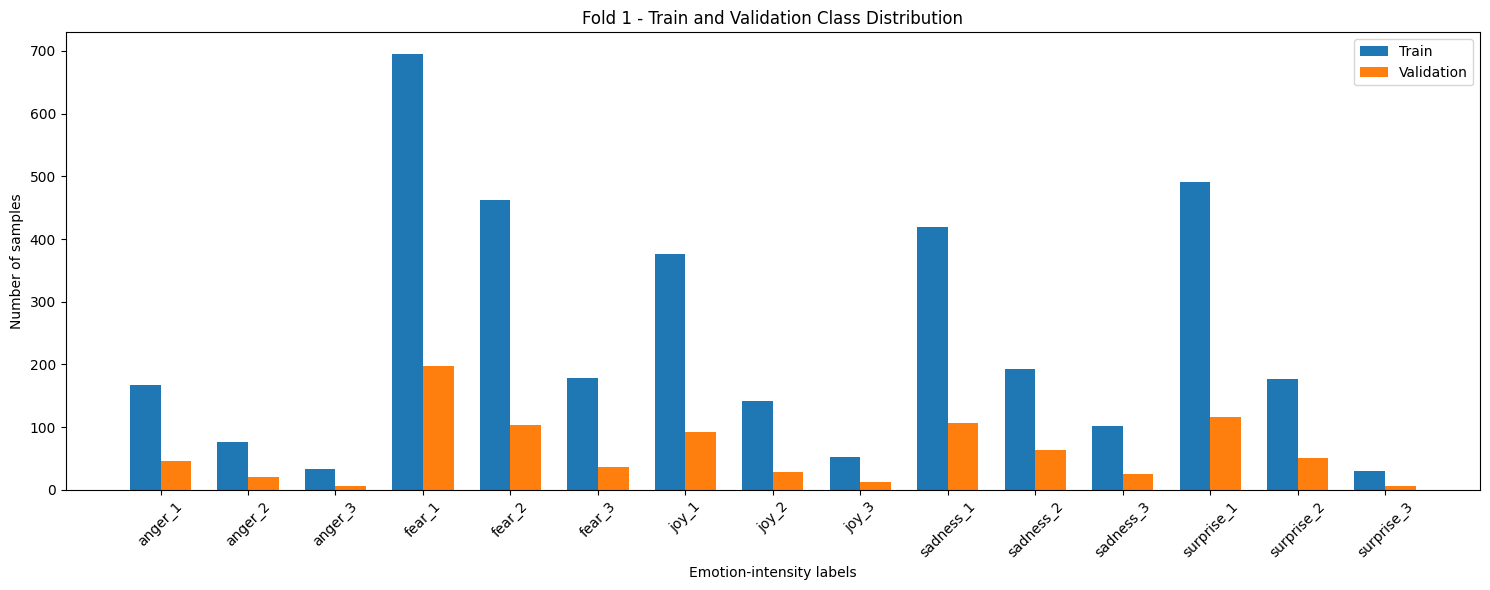

Saved plot: /content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots/Fold_1_Train_Val_Distribution.png


Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.352100,0.298734
2,0.290300,0.276569
3,0.263100,0.269085
4,0.242800,0.258284
5,0.231300,0.257135


Fold train loss: 0.27592096858554416
Fold val loss  : 0.2571350038051605

Fold 2/5
Train size: 2302
Val size  : 576


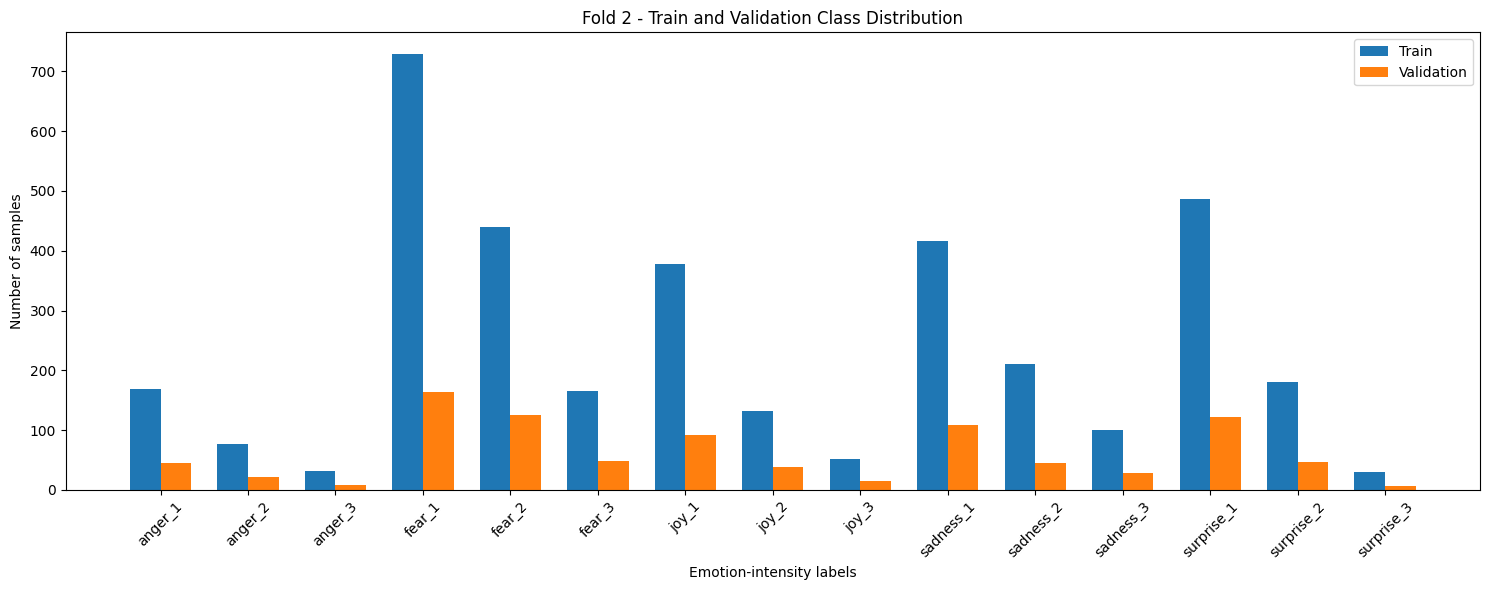

Saved plot: /content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots/Fold_2_Train_Val_Distribution.png


Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.348600,0.302539
2,0.290800,0.279649
3,0.265400,0.266231
4,0.244900,0.257353
5,0.231800,0.255193


Fold train loss: 0.2762998527950711
Fold val loss  : 0.2551933526992798

Fold 3/5
Train size: 2302
Val size  : 576


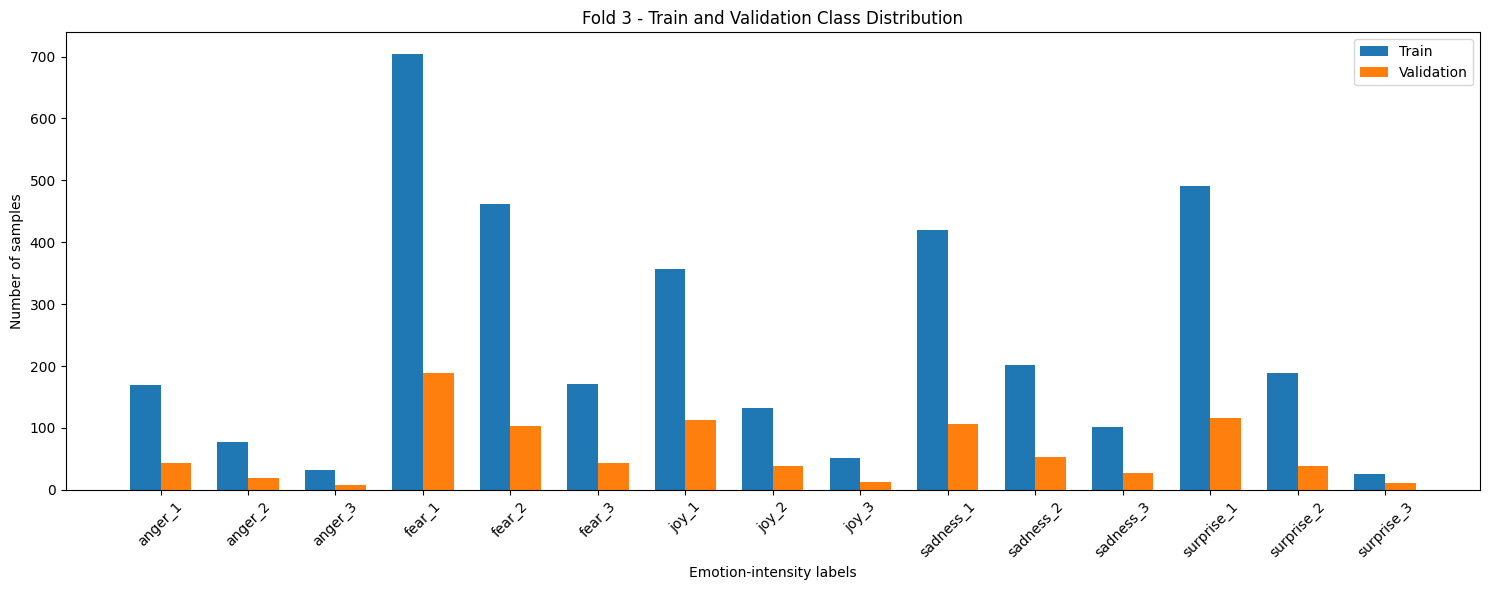

Saved plot: /content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots/Fold_3_Train_Val_Distribution.png


Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.345600,0.301970
2,0.287600,0.279720
3,0.262200,0.261955
4,0.243800,0.256048
5,0.233100,0.252161


Fold train loss: 0.2744774924384223
Fold val loss  : 0.2521608769893646

Fold 4/5
Train size: 2303
Val size  : 575


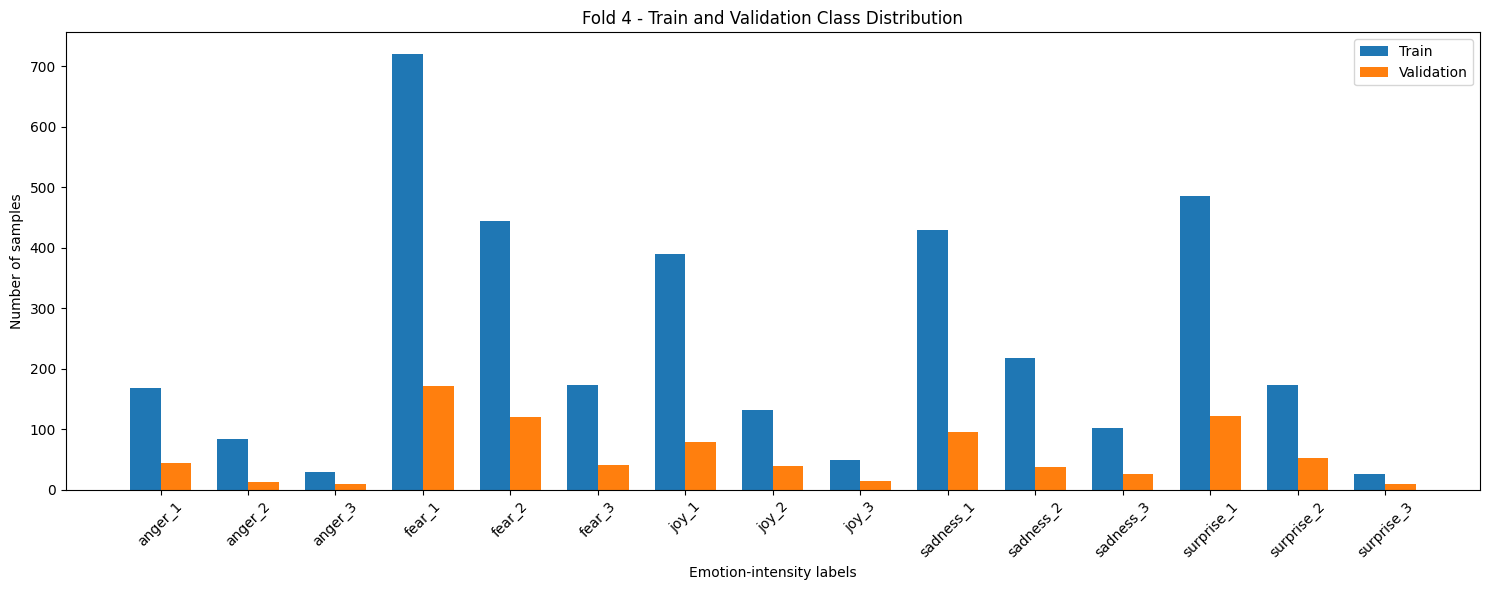

Saved plot: /content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots/Fold_4_Train_Val_Distribution.png


Map:   0%|          | 0/2303 [00:00<?, ? examples/s]

Map:   0%|          | 0/2303 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.350200,0.294015
2,0.288100,0.266860
3,0.256900,0.251761
4,0.235000,0.245686
5,0.222900,0.243542


Fold train loss: 0.27062609990437825
Fold val loss  : 0.24354244768619537

Fold 5/5
Train size: 2303
Val size  : 575


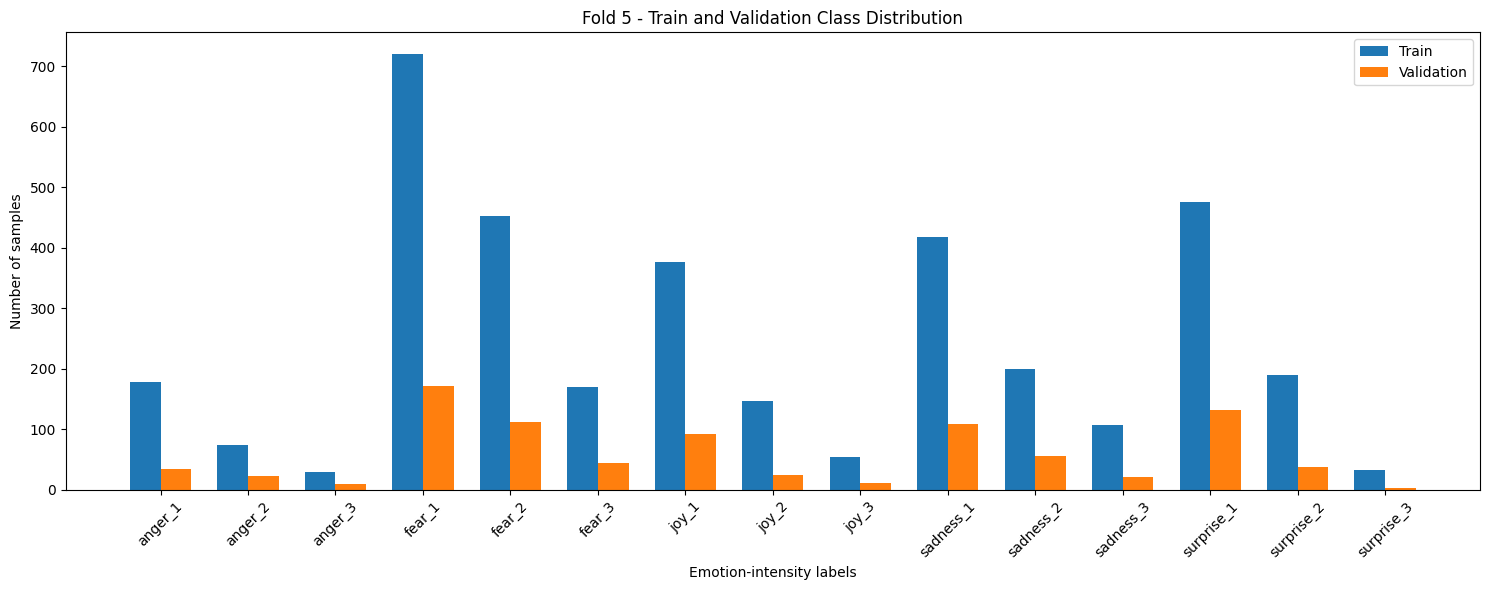

Saved plot: /content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots/Fold_5_Train_Val_Distribution.png


Map:   0%|          | 0/2303 [00:00<?, ? examples/s]

Map:   0%|          | 0/2303 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/2765 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
180,0.343100
360,0.284500
540,0.255000
720,0.233800
900,0.220800


Final training time: 89.18719148635864

FINAL TEST EVALUATION



Final Test Results:
Test loss        : 0.23924030363559723
Test macro F1    : 0.14423734333993402
Test micro F1    : 0.25974942650432326
Test Pearson mean: 0.3932260125875473

Final clean log saved at:
/content/drive/MyDrive/RoBERTa_SingleStep_KFold_Clean_Log.csv

Fold distribution plots saved at:
/content/drive/MyDrive/RoBERTa_KFold_Distribution_Plots


In [5]:
# =========================================================
# 11. K-FOLD CROSS VALIDATION
# =========================================================
kf = KFold(
    n_splits=K,
    shuffle=True,
    random_state=SEED
)

fold_train_losses = []
fold_val_losses = []

cv_start = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(cv_df), start=1):

    print("\n================================")
    print(f"Fold {fold}/{K}")
    print("================================")

    set_seed(SEED + fold)

    fold_train_df = cv_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = cv_df.iloc[val_idx].reset_index(drop=True)

    print("Train size:", len(fold_train_df))
    print("Val size  :", len(fold_val_df))

    # One plot per fold: train + validation together
    plot_fold_distribution(fold, fold_train_df, fold_val_df)

    train_dataset = prepare_dataset(fold_train_df)
    val_dataset = prepare_dataset(fold_val_df)

    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        problem_type="multi_label_classification"
    )

    training_args = TrainingArguments(
        output_dir=f"/content/roberta_kfold_fold_{fold}",

        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=8,
        num_train_epochs=5,

        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED + fold
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator
    )

    train_result = trainer.train()
    eval_result = trainer.evaluate()

    train_loss = train_result.training_loss
    val_loss = eval_result["eval_loss"]

    fold_train_losses.append(train_loss)
    fold_val_losses.append(val_loss)

    with open(LOG_FILE, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([fold, train_loss, val_loss])

    print("Fold train loss:", train_loss)
    print("Fold val loss  :", val_loss)

cv_end = time.time()

# =========================================================
# 12. CROSS-VALIDATION LOSS SUMMARY
# =========================================================
mean_train_loss = np.mean(fold_train_losses)
std_train_loss = np.std(fold_train_losses)

mean_val_loss = np.mean(fold_val_losses)
std_val_loss = np.std(fold_val_losses)

with open(LOG_FILE, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["CROSS-VALIDATION LOSS SUMMARY"])
    writer.writerow(["metric", "mean", "std"])
    writer.writerow(["train_loss", mean_train_loss, std_train_loss])
    writer.writerow(["val_loss", mean_val_loss, std_val_loss])
    writer.writerow(["total_cv_time_seconds", cv_end - cv_start])

print("\n================================")
print("CROSS-VALIDATION COMPLETED")
print("================================")
print("Mean train loss:", mean_train_loss)
print("Mean val loss  :", mean_val_loss)
print("Total CV time  :", cv_end - cv_start)

# =========================================================
# 13. FINAL TRAINING ON COMPLETE TRAIN + DEV
# =========================================================
print("\n================================")
print("FINAL TRAINING ON TRAIN + DEV")
print("================================")

set_seed(SEED)

final_train_dataset = prepare_dataset(cv_df)
final_test_dataset = prepare_dataset(test_single)

final_model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

final_training_args = TrainingArguments(
    output_dir="/content/roberta_single_step_final",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=5,

    logging_strategy="epoch",
    save_strategy="no",

    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=final_train_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

final_train_start = time.time()
final_trainer.train()
final_train_end = time.time()

print("Final training time:", final_train_end - final_train_start)

# =========================================================
# 14. FINAL TEST EVALUATION AFTER COMPLETE CV
# =========================================================
print("\n================================")
print("FINAL TEST EVALUATION")
print("================================")

test_output = final_trainer.predict(final_test_dataset)

logits = test_output.predictions
true_labels = test_output.label_ids

probs = 1 / (1 + np.exp(-logits))
pred_labels = (probs >= 0.5).astype(int)

test_loss = test_output.metrics["test_loss"]

test_f1_macro = f1_score(
    true_labels,
    pred_labels,
    average="macro",
    zero_division=0
)

test_f1_micro = f1_score(
    true_labels,
    pred_labels,
    average="micro",
    zero_division=0
)

pearsons = []

for i in range(true_labels.shape[1]):
    if np.std(true_labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
        pearsons.append(0.0)
    else:
        p, _ = pearsonr(true_labels[:, i], probs[:, i])
        pearsons.append(0.0 if np.isnan(p) else float(p))

test_pearson_mean = float(np.mean(pearsons))

classwise_report = classification_report(
    true_labels,
    pred_labels,
    target_names=LABELS,
    zero_division=0,
    output_dict=True
)

print("\nFinal Test Results:")
print("Test loss        :", test_loss)
print("Test macro F1    :", test_f1_macro)
print("Test micro F1    :", test_f1_micro)
print("Test Pearson mean:", test_pearson_mean)

# =========================================================
# 15. LOG FINAL TEST + CLASSWISE RESULTS
# =========================================================
with open(LOG_FILE, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["FINAL TEST RESULTS AFTER COMPLETE CROSS-VALIDATION"])
    writer.writerow(["metric", "value"])
    writer.writerow(["test_loss", test_loss])
    writer.writerow(["test_f1_macro", test_f1_macro])
    writer.writerow(["test_f1_micro", test_f1_micro])
    writer.writerow(["test_pearson_mean", test_pearson_mean])
    writer.writerow(["final_training_time_seconds", final_train_end - final_train_start])

    writer.writerow([])
    writer.writerow(["FINAL CLASSWISE TEST RESULTS"])
    writer.writerow(["class", "precision", "recall", "f1_score", "support"])

    for label in LABELS:
        row = classwise_report.get(label, {})

        writer.writerow([
            label,
            row.get("precision", ""),
            row.get("recall", ""),
            row.get("f1-score", ""),
            row.get("support", "")
        ])

print("\nFinal clean log saved at:")
print(LOG_FILE)

print("\nFold distribution plots saved at:")
print(PLOT_DIR)